This notebook analyzes the somatic mutational profile of TCGA endometrial carcinoma patient TCGA-A5-A0G2, a 57-year-old female diagnosed with stage IIIB serous endometrial adenocarcinoma. Using mutation annotation format (MAF) data and clinical metadata sourced from cBioPortal, the analysis identifies key driver mutations, characterizes the patient's ultra-mutator phenotype, and contextualizes her mutational landscape within a cohort of endometrial carcinoma patients sharing an exceptionally high tumor mutational burden (≥10,000 somatic variants). The workflow includes cohort filtering, identification of recurrent POLE mutations across the cohort, visualization of POLE mutation frequency via lollipop plot, and confirmation of clinically significant driver mutations in POLE and TP53. Data files required to reproduce this analysis are data_mutations.txt and ucec_tcga_gdc_clinical_data.tsv, both available through the TCGA endometrial carcinoma dataset on cBioPortal.

Parse MAF Data: 

In [14]:
import pandas as pd
mutations_df = pd.read_csv('data_mutations.txt', sep = "\t", comment="#", low_memory=False)  # Load MAF into df
mutations_df['Tumor_Sample_Barcode']
mutations_df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,gnomAD_non_cancer_NFE_AF,gnomAD_non_cancer_OTH_AF,gnomAD_non_cancer_SAS_AF,hotspot,miRNA,n_depth,normal_bam_uuid,t_depth,tumor_bam_uuid,Annotation_Status
0,INTS11,54973.0,WUGSC,GRCh38,1,1313520,1313520,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,NaN,82,4403db46-33b7-4587-8777-a9992f730f57,40,91c728f7-a0ce-443c-8b3a-589ae313634e,SUCCESS
1,NPHP4,261734.0,WUGSC,GRCh38,1,5867789,5867789,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,NaN,23,4403db46-33b7-4587-8777-a9992f730f57,25,91c728f7-a0ce-443c-8b3a-589ae313634e,SUCCESS
2,KIF1B,23095.0,WUGSC,GRCh38,1,10303937,10303937,+,intron_variant,Intron,...,NaN,NaN,NaN,0,NaN,16,4403db46-33b7-4587-8777-a9992f730f57,20,91c728f7-a0ce-443c-8b3a-589ae313634e,SUCCESS
3,AADACL4,343066.0,WUGSC,GRCh38,1,12644594,12644594,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,NaN,117,4403db46-33b7-4587-8777-a9992f730f57,81,91c728f7-a0ce-443c-8b3a-589ae313634e,SUCCESS
4,AADACL4,343066.0,WUGSC,GRCh38,1,12665970,12665970,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,NaN,106,4403db46-33b7-4587-8777-a9992f730f57,86,91c728f7-a0ce-443c-8b3a-589ae313634e,SUCCESS


In [15]:
mutations_df['Tumor_Sample_Barcode_Short'] = mutations_df['Tumor_Sample_Barcode'].str[:15] # Shorten barcodes so that they match TCGA patient codes
print(mutations_df.columns)

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification',
       ...
       'gnomAD_non_cancer_OTH_AF', 'gnomAD_non_cancer_SAS_AF', 'hotspot',
       'miRNA', 'n_depth', 'normal_bam_uuid', 't_depth', 'tumor_bam_uuid',
       'Annotation_Status', 'Tumor_Sample_Barcode_Short'],
      dtype='object', length=141)


In [16]:
clinical_df = pd.read_csv('ucec_tcga_gdc_clinical_data.tsv', sep="\t")  # Load filtered clinical data into df
clinical_df.head()

,Study ID,Patient ID,Sample ID,Diagnosis Age,Biopsy Site,Cancer Type,Cancer Type Detailed,Last Communication Contact from Initial Pathologic Diagnosis Date,Birth from Initial Pathologic Diagnosis Date,Death from Initial Pathologic Diagnosis Date,...,Project Name,Project State,Race Category,Number of Samples Per Patient,Sample Type,Sample type id,Sex,TMB (nonsynonymous),Patient's Vital Status,Year of Diagnosis
0,ucec_tcga_gdc,TCGA-A5-A0G2,TCGA-A5-A0G2-01,57,Endometrial,Endometrial Carcinoma,Endometrial Carcinoma,4054.0,-20953,NaN,...,Endometrial Carcinoma,released,ASIAN,1,Primary Tumor,1,Female,764.333333,Alive,1997
1,ucec_tcga_gdc,TCGA-AP-A0LM,TCGA-AP-A0LM-01,33,Endometrial,Endometrial Carcinoma,Endometrial Carcinoma,825.0,-12309,NaN,...,Endometrial Carcinoma,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,365.400000,Alive,2004
2,ucec_tcga_gdc,TCGA-AP-A1DV,TCGA-AP-A1DV-01,59,Endometrial,Endometrial Carcinoma,Endometrial Carcinoma,204.0,-21901,NaN,...,Endometrial Carcinoma,released,WHITE,1,Primary Tumor,1,Female,350.800000,Alive,2008
3,ucec_tcga_gdc,TCGA-AX-A1CE,TCGA-AX-A1CE-01,60,Endometrial,Endometrial Carcinoma,Endometrial Carcinoma,610.0,-21969,NaN,...,Endometrial Carcinoma,released,WHITE,1,Primary Tumor,1,Female,334.966667,Alive,2009
4,ucec_tcga_gdc,TCGA-AX-A2HC,TCGA-AX-A2HC-01,53,Endometrial,Endometrial Carcinoma,Endometrial Carcinoma,1016.0,-19485,NaN,...,Endometrial Carcinoma,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,385.633333,Alive,2006


Determine top 5 mutations in patient cohort: 

In [17]:
target_patients = clinical_df['Sample ID'] # View patient cohort sample ID's 
print(target_patients)
filtered_df = mutations_df[mutations_df['Tumor_Sample_Barcode_Short'].isin(target_patients)]  # filter from selected cohort

0    TCGA-A5-A0G2-01
1    TCGA-AP-A0LM-01
2    TCGA-AP-A1DV-01
3    TCGA-AX-A1CE-01
4    TCGA-AX-A2HC-01
5    TCGA-B5-A3FC-01
6    TCGA-E6-A1LX-01
7    TCGA-EO-A22R-01
8    TCGA-EO-A22U-01
9    TCGA-FI-A2D5-01
Name: Sample ID, dtype: object


In [18]:
top_5 = filtered_df['Hugo_Symbol'].value_counts().head(5).index.tolist() # Obtain top 5 mutations 
print(top_5)

['TTN', 'MUC16', 'DST', 'RYR2', 'OBSCN']


Determine if patient of interest has top 5 genes: 

In [19]:
patient_interest = filtered_df[filtered_df['Tumor_Sample_Barcode_Short'] == 'TCGA-A5-A0G2-01']


In [20]:
mut_dict = {} 
for mutation in top_5: 
    if mutation in patient_interest['Hugo_Symbol'].values:
        mut_dict[mutation] = 'Yes'
    else: 
        mut_dict[mutation] = 'No'
    

In [21]:
print(mut_dict)

{'TTN': 'Yes', 'MUC16': 'Yes', 'DST': 'Yes', 'RYR2': 'Yes', 'OBSCN': 'Yes'}


Determine top occuring mutations in patient of interest: 

In [22]:
top_values = patient_interest['Hugo_Symbol'].value_counts().head(10)

<AxesSubplot:title={'center':'Top 10 Frequent Values'}>

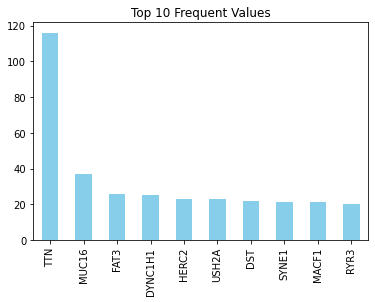

In [23]:
top_values.plot(kind='bar', title='Top 10 Frequent Values', color='skyblue')

Determine if patient of interest has mutations present in POLE Model: 

In [24]:
pole_mut = ['POLE'] # HUGO Symbol for POLE mutation
pole_mut_dict = {}

# if mutation is POLE, add to dict with Yes
for mutation in pole_mut: 
    if mutation in patient_interest['Hugo_Symbol'].values:
        pole_mut_dict[mutation] = 'Yes'
    else: 
        pole_mut_dict[mutation] = 'No'
print(pole_mut_dict)

{'POLE': 'Yes'}


In [25]:
serous_mut = ['TP53'] 
for mutation in serous_mut: 
    if mutation in patient_interest['Hugo_Symbol'].values:
        print("yes")

yes


Create a lollipop plot of POLE mutations

In [27]:
pole_df = filtered_df[filtered_df['Hugo_Symbol'] == 'POLE']

In [28]:
pole_df = filtered_df[filtered_df['Hugo_Symbol']=='POLE'] # df with with only pole mutations 

patient_pole = patient_interest[patient_interest['Hugo_Symbol']=='POLE']
patient_pole = patient_pole[~patient_pole['Variant_Classification'].isin(filter_out)]
print(patient_pole['HGVSp_Short'])

537149    p.S2084L
537152     p.P696S
537153     p.M562T
537154     p.V411L
537155     p.R114*
Name: HGVSp_Short, dtype: object


In [29]:
# Filter out non-pathogenic changes 
filter_out = ['Silent', 'Intron', "3'UTR", "3'Flank"]
pole_df = pole_df[~pole_df['Variant_Classification'].isin(filter_out)]
print(pole_df['HGVSp_Short'])

80778      p.E978G
80779      p.P916L
80780      p.R742H
120564     p.V411L
166690     p.A426V
166691     p.M295R
219238    p.R2127*
219239    p.V1799A
219240    p.R1286C
219241     p.P916L
219243     p.L424I
306213     p.V411L
306214     p.Q214R
369554     p.S297F
436383    p.I1568V
436384     p.V411L
501741    p.A1990V
501742    p.S1906Y
501743    p.R1870C
501746     p.P286R
501747      p.S30L
537149    p.S2084L
537152     p.P696S
537153     p.M562T
537154     p.V411L
537155     p.R114*
579156    p.R1826W
579158    p.L1235I
579160     p.P286R
579162     p.S118Y
Name: HGVSp_Short, dtype: object


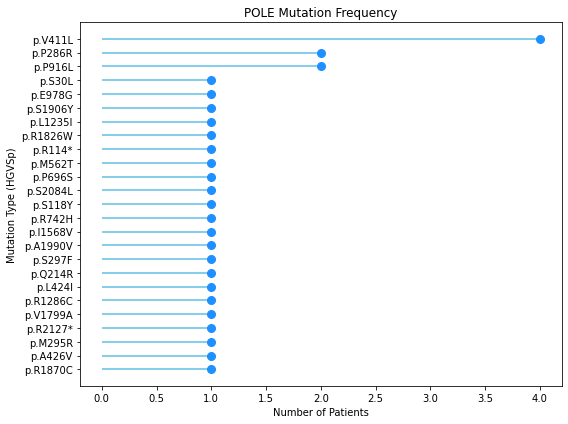

In [33]:
import matplotlib.pyplot as plt
counts = pole_df['HGVSp_Short'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6)) # Create figure 

ax.hlines(y=counts.index, xmin=0, xmax=counts.values, color='skyblue', linewidth=2) # Draw sticks 

ax.plot(counts.values, counts.index, "o", markersize=8, color='dodgerblue') # Add 'lollipops'

# Plot formatting
ax.set_title('POLE Mutation Frequency')
ax.set_xlabel('Number of Patients')
ax.set_ylabel('Mutation Type (HGVSp)')
plt.tight_layout()
plt.show()

Determine if selected patient has top occuring POLE mutations (top occuring in selected cohort) 

In [34]:

mut_dict = {} 
top_pole = ['p.V411L', 'p.P286R', 'p.P916L']
# add to dict if mutation is present 
for mutation in top_pole: 
    if mutation in patient_interest['HGVSp_Short'].values:
        mut_dict[mutation] = 'Yes'
    else: 
        mut_dict[mutation] = 'No'
print(mut_dict)   



{'p.V411L': 'Yes', 'p.P286R': 'No', 'P916L': 'No'}


Choose 2 mutational drivers from patient of interest (TP53 and POLE): 

In [35]:
driver_mut = ['POLE', 'TP53']
patient_interest_driver = patient_interest[patient_interest['Hugo_Symbol'].isin(driver_mut)] # Filter for driver mutations 
print(patient_interest_driver)

       Hugo_Symbol  Entrez_Gene_Id Center NCBI_Build Chromosome  \
537148        POLE          5426.0  WUGSC     GRCh38         12   
537149        POLE          5426.0  WUGSC     GRCh38         12   
537150        POLE          5426.0  WUGSC     GRCh38         12   
537151        POLE          5426.0  WUGSC     GRCh38         12   
537152        POLE          5426.0  WUGSC     GRCh38         12   
537153        POLE          5426.0  WUGSC     GRCh38         12   
537154        POLE          5426.0  WUGSC     GRCh38         12   
537155        POLE          5426.0  WUGSC     GRCh38         12   
541392        TP53          7157.0  WUGSC     GRCh38         17   
541393        TP53          7157.0  WUGSC     GRCh38         17   
541394        TP53          7157.0  WUGSC     GRCh38         17   

        Start_Position  End_Position Strand  \
537148       132621521     132621521      +   
537149       132632394     132632394      +   
537150       132649731     132649731      +   
537151 

Determine the exact TP53 mutations experienced by the patient: 

In [36]:
tp53df = patient_interest[patient_interest['Hugo_Symbol']=='TP53']
print(tp53df['HGVSp_Short'])

541392    p.R379C
541393    p.R342*
541394    p.S241F
Name: HGVSp_Short, dtype: object
